# Figure 3 — Foundation validation: masked-band reconstruction (held-out tile)

Validation of the frozen v10 foundation on a **held-out** ECDFS tile (validation split, unseen
in training). Each band is withheld in turn and reconstructed from the other nine (the
pre-training objective). **Rows:** truth / prediction / per-band pred-vs-truth scatter on the
brightest pixels (with correlation r and the 1:1 line). Across all 39 held-out tiles the mean
per-band r ranges from 0.85 (Euclid VIS) to 0.99 (Rubin g/r/i), with the shallow Rubin u at
0.64.

Pure inference on `models/checkpoints/jaisp_v10_warmstart/checkpoint_best.pt`. Saves
`paper/figures/fig3_reconstruction.png`.

In [1]:
import sys, numpy as np, torch
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from astropy.visualization import ImageNormalize, AsinhStretch, PercentileInterval

def find_repo_root():
    for c in [Path.cwd(), *Path.cwd().parents]:
        if (c / 'data').is_dir() and (c / 'paper').is_dir():
            return c
    raise RuntimeError('repo root not found')

REPO = find_repo_root()
sys.path.insert(0, str(REPO / 'models'))
FIGDIR = REPO / 'paper' / 'figures'; FIGDIR.mkdir(exist_ok=True)
from load_foundation import load_foundation
from jaisp_dataset_v10 import JAISPDatasetV10

CKPT = REPO / 'models' / 'checkpoints' / 'jaisp_v10_warmstart' / 'checkpoint_best.pt'
dev = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

ckpt = torch.load(str(CKPT), map_location='cpu', weights_only=False)
VAL_IDX = set(ckpt['val_indices'])
HELDOUT_IDX = 786   # representative held-out tile: rich field, resolved galaxies, strong u

model = load_foundation(str(CKPT), device=dev, freeze=True)
ds = JAISPDatasetV10(rubin_dir=str(REPO/'data'/'rubin_tiles_all'),
                     euclid_dir=str(REPO/'data'/'euclid_tiles_all'),
                     load_euclid=True, augment=False)
assert HELDOUT_IDX in VAL_IDX, 'chosen tile is NOT in the validation split!'
TILE = ds.tiles[HELDOUT_IDX]['tile_id']
sample = ds[HELDOUT_IDX]
pool = {}; pool.update(sample['rubin']); pool.update(sample.get('euclid', {}))
print('held-out tile:', TILE, '| in val split:', HELDOUT_IDX in VAL_IDX)

JAISPFoundationV10: 9.2M trainable parameters
  stem_ch=64, hidden_ch=256, fused_scale=0.40"/px
  stream_depths={'rubin': 1, 'euclid': 2}
  rubin_concat=True  (symmetric concat fusion)
  loss_type=charbonnier  charbonnier_eps=0.001  core_l2_weight=0.2  core_info_thr=0.5
  rubin decoder channels: [128]
  euclid decoder channels: [256, 128]
Loaded v10 foundation (fused_scale=0.4, rubin_concat=True, loss=charbonnier, core_l2=0.2) from /home/shemmati/Work/Projects/JAISP/models/checkpoints/jaisp_v10_warmstart/checkpoint_best.pt
JAISPDatasetV10: scanning 790 tiles...


  790 tiles passed quality cuts
  790 tiles have Euclid coverage


held-out tile: tile_x02816_y02816_tract5063_patch_14 | in val split: True


In [2]:
ORDER = ['rubin_u','rubin_g','rubin_r','rubin_i','rubin_z','rubin_y',
         'euclid_VIS','euclid_Y','euclid_J','euclid_H']
ORDER = [b for b in ORDER if b in pool]
PSCALE = {b: (0.2 if b.startswith('rubin') else 0.1) for b in ORDER}
FOV = 40.0  # arcsec central crop for the images

def cc(a, ps):
    h = int(round(FOV/ps/2)); c0, c1 = a.shape[0]//2, a.shape[1]//2
    return a[c0-h:c0+h, c1-h:c1+h]

res = {}
for b in ORDER:
    ctx = [x for x in pool if x != b]
    ci = {x: pool[x]['image'].unsqueeze(0).to(dev) for x in ctx}
    cr = {x: pool[x]['rms'].unsqueeze(0).to(dev) for x in ctx}
    ti = pool[b]['image'].unsqueeze(0).to(dev); tr = pool[b]['rms'].unsqueeze(0).to(dev)
    with torch.no_grad():
        out = model(ci, cr, b, ti, tr)
    truth = out['target_norm'][0,0].cpu().numpy()
    pred  = out['pred'][0,0].cpu().numpy()
    info  = out['info_weights'][0,0].cpu().numpy()
    m = info >= np.nanpercentile(info, 90)
    r = float(np.corrcoef(truth[m], pred[m])[0,1])
    tb, pb = truth[m], pred[m]
    k = min(len(tb), 600); sel = np.linspace(0, len(tb)-1, k).astype(int)
    res[b] = dict(truth=cc(truth, PSCALE[b]), pred=cc(pred, PSCALE[b]), r=r,
                  st=tb[sel], sp=pb[sel])
    print(f'{b:11s} r={r:.3f}')

rubin_u     r=0.962


rubin_g     r=0.996


rubin_r     r=0.997


rubin_i     r=0.996


rubin_z     r=0.996


rubin_y     r=0.960


euclid_VIS  r=0.898


euclid_Y    r=0.846


euclid_J    r=0.927


euclid_H    r=0.950


saved /home/shemmati/Work/Projects/JAISP/paper/figures/fig3_reconstruction.png


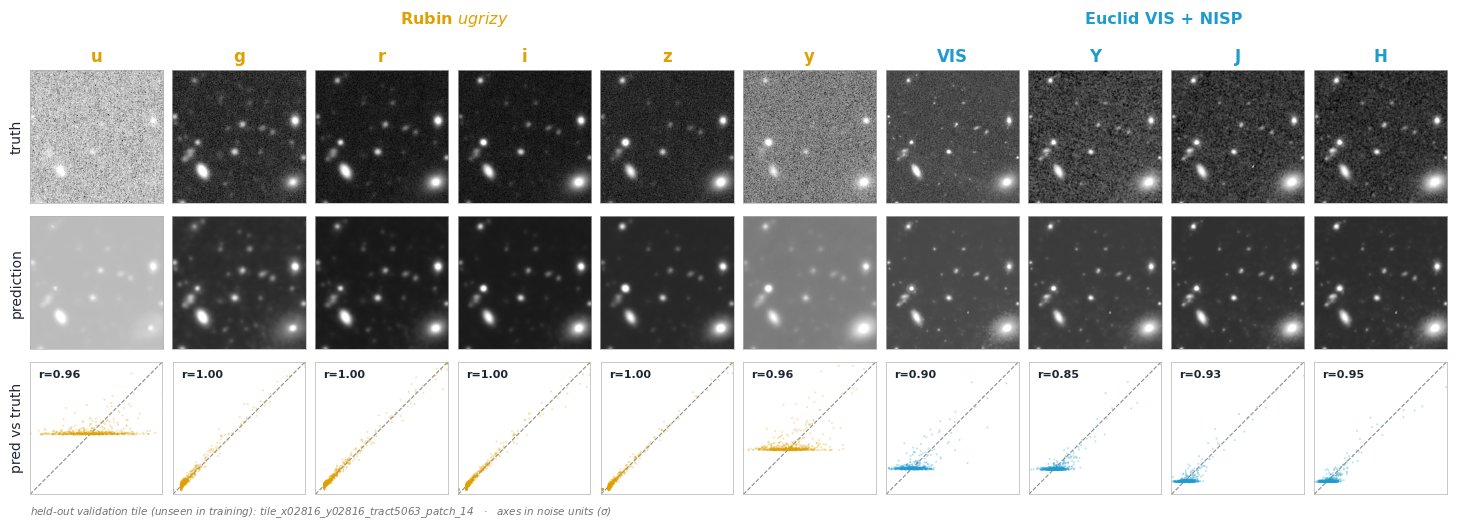

In [3]:
C_RUBIN = '#e0a000'; C_EUCLID = '#1f9bcf'; INK = '#1c2733'
LAB = {'rubin_u':'u','rubin_g':'g','rubin_r':'r','rubin_i':'i','rubin_z':'z','rubin_y':'y',
       'euclid_VIS':'VIS','euclid_Y':'Y','euclid_J':'J','euclid_H':'H'}
nb_ = len(ORDER)

fig = plt.figure(figsize=(15.0, 5.2))
gs = GridSpec(3, nb_, figure=fig, height_ratios=[1, 1, 1], wspace=0.07, hspace=0.10,
              left=0.05, right=0.995, top=0.86, bottom=0.045)
rowlab = ['truth', 'prediction', 'pred vs truth']
for j, b in enumerate(ORDER):
    d = res[b]; col = C_RUBIN if b.startswith('rubin') else C_EUCLID
    nrm = ImageNormalize(d['truth'], interval=PercentileInterval(99.3), stretch=AsinhStretch(0.1))
    # row 0 truth, row 1 prediction
    for i, key in enumerate(['truth', 'pred']):
        ax = fig.add_subplot(gs[i, j])
        ax.imshow(d[key], origin='lower', cmap='gray', norm=nrm, aspect='auto')
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values(): s.set_edgecolor('0.7'); s.set_linewidth(0.5)
        if i == 0:
            ax.set_title(LAB[b], fontsize=12, color=col, weight='bold', pad=6)
        if j == 0:
            ax.set_ylabel(rowlab[i], fontsize=10, color=INK)
    # row 2 per-band scatter
    axs = fig.add_subplot(gs[2, j])
    st, sp = d['st'], d['sp']
    hi = np.nanpercentile(np.concatenate([st, sp]), 99.5); lo = min(st.min(), sp.min(), 0)
    axs.plot([lo, hi], [lo, hi], '--', color='0.55', lw=0.8, zorder=1)
    axs.scatter(st, sp, s=2.0, c=col, alpha=0.30, edgecolors='none', zorder=2)
    axs.set_xlim(lo, hi); axs.set_ylim(lo, hi); axs.set_aspect('equal', 'box')
    axs.set_xticks([]); axs.set_yticks([])
    for s in axs.spines.values(): s.set_edgecolor('0.7'); s.set_linewidth(0.5)
    axs.text(0.06, 0.94, f"r={d['r']:.2f}", transform=axs.transAxes, ha='left', va='top',
             fontsize=8, color=INK, weight='bold')
    if j == 0:
        axs.set_ylabel(rowlab[2], fontsize=10, color=INK)

# instrument group labels
fig.text(0.05 + (3.0/nb_)*0.945, 0.95, 'Rubin $ugrizy$', ha='center', fontsize=11.5,
         color=C_RUBIN, weight='bold')
fig.text(0.05 + (8.0/nb_)*0.945, 0.95, 'Euclid VIS + NISP', ha='center', fontsize=11.5,
         color=C_EUCLID, weight='bold')
fig.text(0.05, 0.005, 'held-out validation tile (unseen in training): %s   ·   axes in noise units ($\sigma$)' % TILE,
         fontsize=7.5, color='0.45', style='italic')

out = FIGDIR / 'fig3_reconstruction.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
print('saved', out)
plt.show()